# Full Initialization Workflow - Package

This notebook initializes a dynamic Modelica model that belongs to a package.

It takes the input package from `models/`, creates the auxiliary package, uses it to compute the initialization values, and generates the initialized package in `outputs/`.


In [1]:
include("../scripts/dictionaries.jl")
include("../scripts/helpers.jl")

using .WorkflowHelpers
using OMJulia


In [2]:
# User configuration: edit the values below for your package.

# Name of the package root model to initialize.
MODEL = "MyIEEE14.IEEE14DisconnectLine"

# Your Dynawo installation (used only for its Modelica Standard Library).
DYNAWO_DIR = "/home/clarafercas/dynawo"
MODELICA_PKG_PATH = "$DYNAWO_DIR/OpenModelica/lib/omlibrary/Modelica/package.mo"

# Dynawo Modelica library from this repo.
DYNAWO_PKG_PATH = abspath("../dynawo_library/Dynawo/package.mo")

# Optional settings

# INIT model selection for components with multiple INIT profiles.
INIT_MODEL_BY_COMPONENT = Dict{String, String}()

# Leave empty to disable slack-specific handling.
SLACK_COMPONENT = "Gen1";


In [3]:
# Internal paths derived from the user configuration above.
SOURCE_PACKAGE = split(MODEL, ".")[1]
MODEL_DIR = abspath(joinpath("models", SOURCE_PACKAGE))
OUTPUT_DIR = abspath("outputs")

PATHS = package_workflow_paths(MODEL, MODEL_DIR, OUTPUT_DIR)

MODELS_PKG_PATH = PATHS.source_package_file

AUX_PACKAGE = PATHS.aux_package
AUX_DIR = PATHS.aux_dir
AUX_ROOT_MODEL = PATHS.aux_root_model
AUX_PACKAGE_FILE = PATHS.aux_package_file
AUX_ORDER_FILE = PATHS.aux_order_file

INITIALIZED_PACKAGE = PATHS.initialized_package
INITIALIZED_DIR = PATHS.initialized_dir
INITIALIZED_ROOT_MODEL = PATHS.initialized_root_model
INITIALIZED_PACKAGE_FILE = PATHS.initialized_package_file
INITIALIZED_ORDER_FILE = PATHS.initialized_order_file

isfile(MODELS_PKG_PATH) || error("Package file not found: $MODELS_PKG_PATH")
isfile(DYNAWO_PKG_PATH) || error("Dynawo package not found: $DYNAWO_PKG_PATH")
isfile(MODELICA_PKG_PATH) || error("Modelica package not found: $MODELICA_PKG_PATH")
isdir(OUTPUT_DIR) || error("Output directory not found: $OUTPUT_DIR")

true

## Build Auxiliary Package

The original package root model is loaded and checked before any changes are made. An auxiliary package is then generated and saved for the initialization simulation.


In [4]:
DynamicOMC = OMJulia.OMCSession()
omc_call(DynamicOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(DynamicOMC, "loadModel(Complex)")
omc_call(DynamicOMC, "loadModel(ModelicaServices)")
omc_call(DynamicOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(DynamicOMC, "loadFile(\"$MODELS_PKG_PATH\")")

check_user_configuration_package(DynamicOMC;
    model = MODEL,
    slack_component = SLACK_COMPONENT,
    init_model_by_component = INIT_MODEL_BY_COMPONENT,
)

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.wSRrJQoXz6"


Configuration checked successfully


(model_chain = ["MyIEEE14.IEEE14Base", "MyIEEE14.IEEE14DisconnectLine"], parameter_model = "")

In [5]:
chain = get_inheritance_chain(DynamicOMC, MODEL)
AUX_NAME_MAP = auxiliary_name_map(chain, AUX_PACKAGE)

package_context = collect_package_component_contexts(DynamicOMC, chain)
components_by_model = package_context.components_by_model
patch_components_by_model = package_context.patch_components_by_model
global_blacklist_names = package_context.global_blacklist_names

# Drop any class left over from a previous run. A missing class is fine here.
sendExpression(DynamicOMC, "deleteClass($AUX_PACKAGE)")
omc_call(DynamicOMC, "loadString(\"within ; package $AUX_PACKAGE end $AUX_PACKAGE;\")", parsed = false)

for model in chain
    aux_model = AUX_NAME_MAP[model]
    aux_name = split(aux_model, ".")[end]

    println("Creating auxiliary model $aux_model from $model")
    omc_call(DynamicOMC, "copyClass($model, \"$aux_name\", $AUX_PACKAGE)")

    components = components_by_model[model]

    apply_replacements!(
        DynamicOMC,
        model,
        aux_model,
        components,
        SLACK_COMPONENT,
    )

    delete_connections!(DynamicOMC, aux_model, components; global_targets = global_blacklist_names)
    delete_components!(DynamicOMC, aux_model, components)

    add_init_models!(
        DynamicOMC,
        model,
        aux_model,
        components,
        INIT_MODEL_BY_COMPONENT,
        SLACK_COMPONENT,
    )

    apply_LF_modifiers!(
        DynamicOMC,
        model,
        aux_model,
        components,
    )

    add_init_equations!(
        DynamicOMC,
        model,
        aux_model,
        components,
        INIT_MODEL_BY_COMPONENT,
        SLACK_COMPONENT,
    )
end

isdir(AUX_DIR) && rm(AUX_DIR; recursive = true, force = true)
mkpath(AUX_DIR)

write_package_files!(
    AUX_PACKAGE_FILE,
    AUX_ORDER_FILE,
    AUX_PACKAGE,
    package_class_names(chain, AUX_NAME_MAP),
)

save_auxiliary_package_classes!(
    DynamicOMC,
    chain,
    AUX_NAME_MAP,
    AUX_DIR,
    patch_components_by_model,
    SLACK_COMPONENT,
)

omc_call(DynamicOMC, "deleteClass($AUX_PACKAGE)")
omc_call(DynamicOMC, "loadFile(\"$AUX_PACKAGE_FILE\")")
omc_call(DynamicOMC, "checkModel($AUX_ROOT_MODEL)", parsed = false)

println("Wrote auxiliary package: ", AUX_DIR)


Creating auxiliary model MyIEEE14_auxiliary.IEEE14Base_auxiliary from MyIEEE14.IEEE14Base


Creating auxiliary model MyIEEE14_auxiliary.IEEE14DisconnectLine_auxiliary from MyIEEE14.IEEE14DisconnectLine


Wrote auxiliary package: /home/clarafercas/dynawo-notebooks/OpenModelica_only_users/FullWorkflow/outputs/MyIEEE14_auxiliary


## Extract Initialization Values

The written auxiliary package is loaded independently, checked, and simulated. Its simulation outputs provide the initialization values to apply to the original dynamic package.


In [6]:
AuxiliaryOMC = OMJulia.OMCSession()
omc_call(AuxiliaryOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(AuxiliaryOMC, "loadModel(Complex)")
omc_call(AuxiliaryOMC, "loadModel(ModelicaServices)")
omc_call(AuxiliaryOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(AuxiliaryOMC, "loadFile(\"$AUX_PACKAGE_FILE\")")

omc_call(AuxiliaryOMC, "checkModel($AUX_ROOT_MODEL)", parsed = false)
println("Auxiliary package root model checked successfully.")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.yC3UsSqegO"


Auxiliary package root model checked successfully.


In [7]:
ModelicaSystem(AuxiliaryOMC, AUX_PACKAGE_FILE, AUX_ROOT_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(AuxiliaryOMC, resultfile = AUX_PACKAGE * "_res.mat")

initializable_by_model = Dict{String, Dict{String, Dict{String, Any}}}()
init_values_by_model = Dict{String, Dict{String, Dict{String, Float64}}}()

for model in chain
    components = components_by_model[model]
    initializable_components = get_initializable_components(components, INIT_MODEL_BY_COMPONENT)
    init_values_by_component = extract_all_initialization_values(
        AuxiliaryOMC,
        components,
        INIT_MODEL_BY_COMPONENT,
    )

    initializable_by_model[model] = initializable_components
    init_values_by_model[model] = init_values_by_component
end

for model in chain
    initialized_component_names = sort(collect(keys(init_values_by_model[model])))
    label = isempty(initialized_component_names) ? "<none>" : join(initialized_component_names, ", ")
    println("Extracted initialization values for $model: $label")
end


Extracted initialization values for MyIEEE14.IEEE14Base: Gen1, Gen2, Gen3, Gen6, Gen8, Load10, Load11, Load12, Load13, Load14, Load2, Load3, Load4, Load5, Load6, Load9


Extracted initialization values for MyIEEE14.IEEE14DisconnectLine: <none>


## Build Initialized Package

A copy of the validated original dynamic package is populated with the values extracted from the auxiliary simulation and saved as the initialized package.


In [8]:
INITIALIZED_NAME_MAP = initialized_name_map(chain, INITIALIZED_PACKAGE)

# Drop any class left over from a previous run. A missing class is fine here.
sendExpression(DynamicOMC, "deleteClass($INITIALIZED_PACKAGE)")
omc_call(DynamicOMC, "loadString(\"within ; package $INITIALIZED_PACKAGE end $INITIALIZED_PACKAGE;\")", parsed = false)

for model in chain
    initialized_model = INITIALIZED_NAME_MAP[model]
    initialized_name = split(initialized_model, ".")[end]

    println("Creating initialized model $initialized_model from $model")
    omc_call(DynamicOMC, "copyClass($model, \"$initialized_name\", $INITIALIZED_PACKAGE)")

    apply_initialization_modifiers!(
        DynamicOMC,
        initialized_model,
        initializable_by_model[model],
        init_values_by_model[model],
        INIT_MODEL_BY_COMPONENT,
    )
end

isdir(INITIALIZED_DIR) && rm(INITIALIZED_DIR; recursive = true, force = true)
mkpath(INITIALIZED_DIR)

write_package_files!(
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ORDER_FILE,
    INITIALIZED_PACKAGE,
    package_class_names(chain, INITIALIZED_NAME_MAP),
)

save_initialized_package_classes!(
    DynamicOMC,
    chain,
    INITIALIZED_NAME_MAP,
    INITIALIZED_DIR,
)

println("Wrote initialized package: ", INITIALIZED_DIR)


Creating initialized model MyIEEE14_initialized.IEEE14Base_initialized from MyIEEE14.IEEE14Base


Creating initialized model MyIEEE14_initialized.IEEE14DisconnectLine_initialized from MyIEEE14.IEEE14DisconnectLine


Wrote initialized package: /home/clarafercas/dynawo-notebooks/OpenModelica_only_users/FullWorkflow/outputs/MyIEEE14_initialized


## Validate Initialized Package

The generated initialized package is loaded independently and simulated to verify that the final output can run.


In [9]:
InitializedOMC = OMJulia.OMCSession()
omc_call(InitializedOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(InitializedOMC, "loadModel(Complex)")
omc_call(InitializedOMC, "loadModel(ModelicaServices)")
omc_call(InitializedOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(InitializedOMC, "loadFile(\"$INITIALIZED_PACKAGE_FILE\")")

omc_call(InitializedOMC, "checkModel($INITIALIZED_ROOT_MODEL)", parsed = false)
println("Initialized package root model checked successfully.")

ModelicaSystem(
    InitializedOMC,
    INITIALIZED_PACKAGE_FILE,
    INITIALIZED_ROOT_MODEL,
    [MODELICA_PKG_PATH, DYNAWO_PKG_PATH],
)

simflags = simulation_flags_without_log_stats(InitializedOMC, INITIALIZED_ROOT_MODEL)
initialized_resultfile_prefix = INITIALIZED_PACKAGE

sendExpression(
    InitializedOMC,
    "simulate($INITIALIZED_ROOT_MODEL, outputFormat=\"csv\", fileNamePrefix=\"$initialized_resultfile_prefix\", simflags=\"$simflags\")",
    parsed = false,
)

initialized_resultfile = joinpath(
    getWorkDirectory(InitializedOMC),
    initialized_resultfile_prefix * "_res.csv",
)
println("Initialized package simulated successfully.")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.NBv4sQI8T7"


Initialized package root model checked successfully.


Initialized package simulated successfully.


## Optional: Plot Simulation Result

The final cell is an optional example of visualizing a variable from the initialized-package simulation result.


WebIO._IJuliaInit()

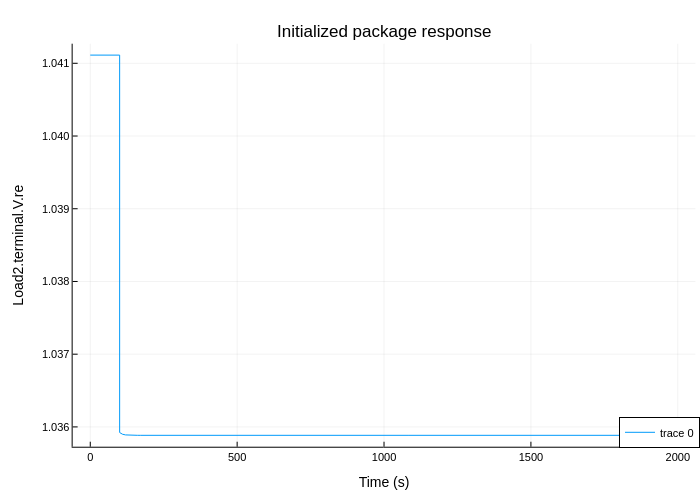

In [10]:
using Plots, DataFrames, CSV

# Select a variable to visualize from the initialized simulation.
PLOT_VARIABLE = "Load2.terminal.V.re"

result_columns = names(DataFrame(CSV.File(initialized_resultfile; limit = 0)))
PLOT_VARIABLE in result_columns ||
    error("PLOT_VARIABLE \"$PLOT_VARIABLE\" is not a variable in the simulation result.")
initialized_df = DataFrame(CSV.File(initialized_resultfile; select = ["time", PLOT_VARIABLE]))

plotlyjs()
p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized package response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)
